In [30]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import RiverFlowDynamics
import matplotlib.pyplot as plt
from landlab.plot.imshow import imshow_grid
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation

In [47]:
# make channel grid
n_rows, n_cols = 40, 200
xy_spacing = 0.05
grid = RasterModelGrid((n_rows, n_cols), xy_spacing=xy_spacing)

# bed topography
z = grid.add_zeros("topographic__elevation", at="node")
z += 2.0 - 0.01 * grid.x_of_node
wall_x = 2
wall_thickness = 0.2
wall_height = 1.0
notch_width = .2
domain_center = (n_rows*xy_spacing)/2
notch_right = domain_center-(notch_width/2)
notch_left = domain_center+(notch_width/2)
wall_slice = (grid.x_of_node >= wall_x) & (grid.x_of_node <= (wall_x + wall_thickness))
notch_opening = (grid.y_of_node >= notch_right) & (grid.y_of_node <= notch_left)
notch_wall_mask = wall_slice & ~notch_opening
z[notch_wall_mask] += wall_height

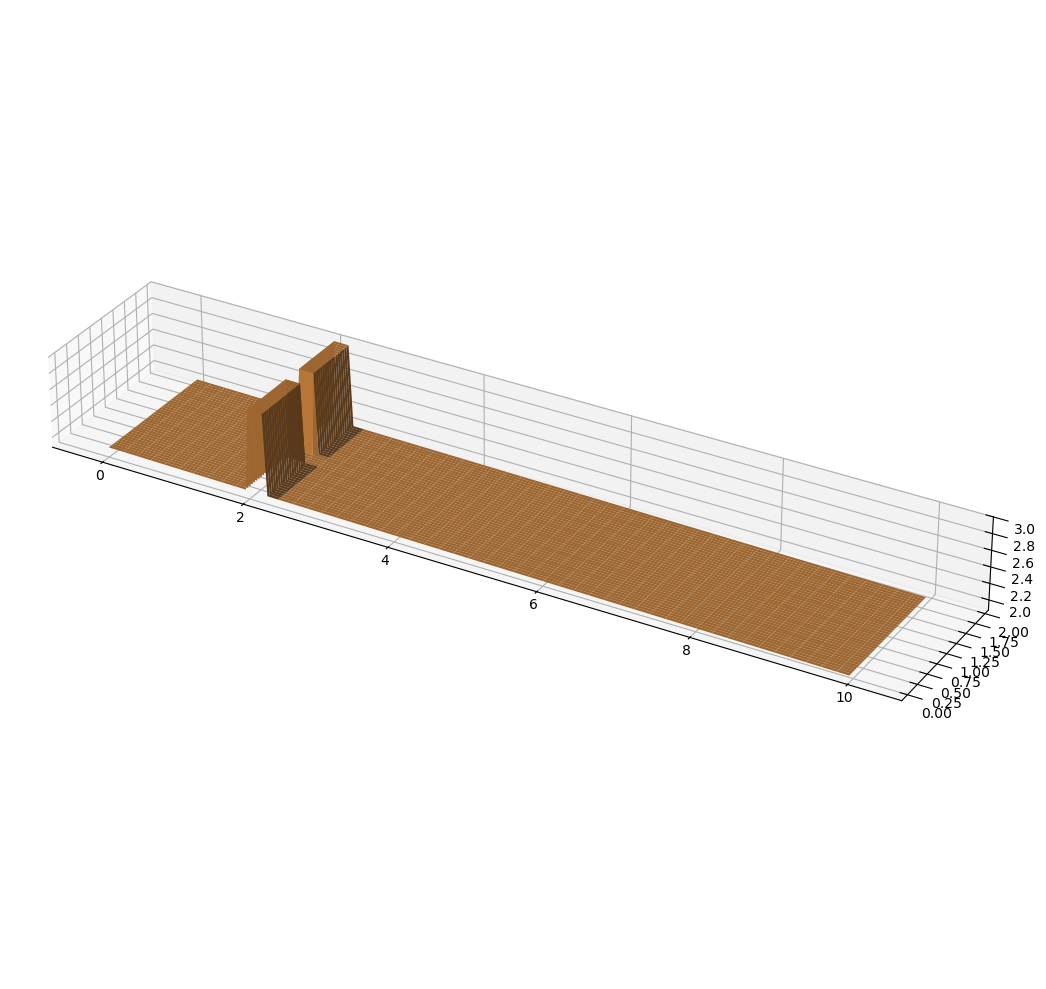

In [48]:
# plot setup 3d
X = grid.x_of_node.reshape(grid.shape)
Y = grid.y_of_node.reshape(grid.shape)
Z = z.reshape(grid.shape)

x_range = X.max() - X.min()  
y_range = Y.max() - Y.min()  
z_range = Z.max() - Z.min() 
vertical_exaggeration = 1  
scaled_z_range = z_range * vertical_exaggeration

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))

surf = ax.plot_surface(
    X, Y, Z, 
    color="peru",      
    edgecolor="none",    
    antialiased=True
)

ax.set_box_aspect((x_range, y_range, scaled_z_range))
ax.view_init(elev=30, azim=-60)
plt.tight_layout()
plt.show()

In [49]:
# boundaries
grid.set_closed_boundaries_at_grid_edges(False, True, False, True)

# define inlet
inlet_nodes = grid.nodes_at_left_edge

inlet_nodes = inlet_nodes[
    (grid.y_of_node[inlet_nodes] > grid.y_of_node.min()) & 
    (grid.y_of_node[inlet_nodes] < grid.y_of_node.max())
]

inlet_links = grid.links_at_node[inlet_nodes][:, 0]

# water params
h = grid.add_zeros("surface_water__depth", at="node")
h[:] = 0.0  # add a small base depth if unstable (~.05)
vel = grid.add_zeros("surface_water__velocity", at="link")
wse = grid.add_zeros("surface_water__elevation", at="node")
wse[:] = h + z

# initialize
rfd = RiverFlowDynamics(
    grid,
    mannings_n=0.03,
    fixed_entry_nodes=inlet_nodes,
    fixed_entry_links=inlet_links,
    entry_nodes_h_values=np.full(len(inlet_nodes), 0.5),
    entry_links_vel_values=np.full(len(inlet_links), 0.3)
)

In [50]:
# run and save wse frames
n_timesteps = 800
wse_history = []
for timestep in range(n_timesteps):
    rfd.run_one_step()

    if timestep % 2 == 0:
        current_wse = grid.at_node["topographic__elevation"] + grid.at_node["surface_water__depth"]
        wse_history.append(current_wse.copy())

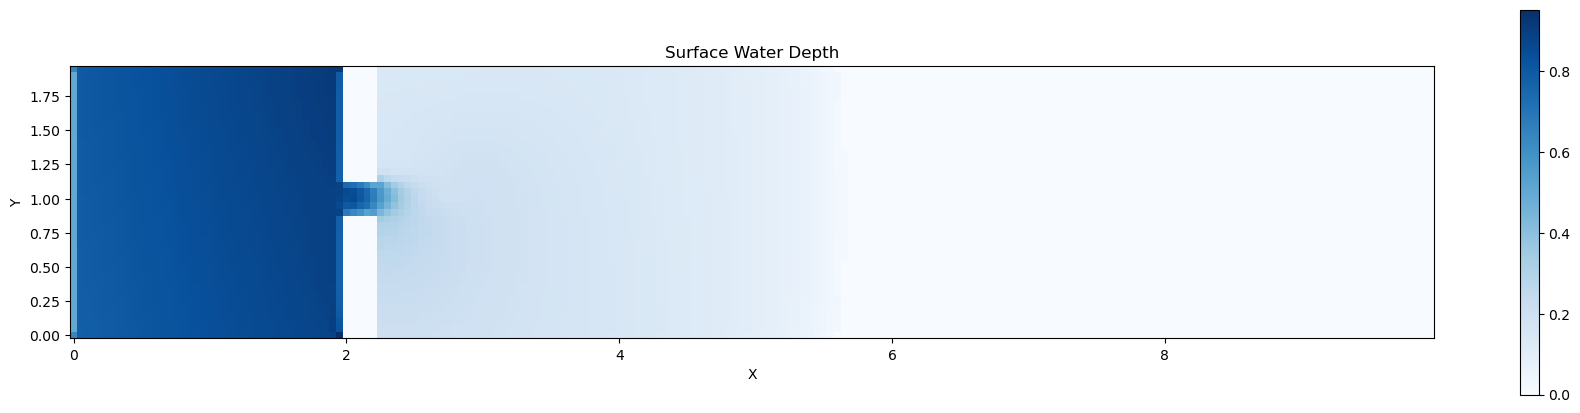

In [51]:
# plot water depth
fig, ax = plt.subplots(figsize=(22, 5))

imshow_grid(grid, "surface_water__depth", at="node", cmap="Blues")
plt.title("Surface Water Depth")

plt.show()

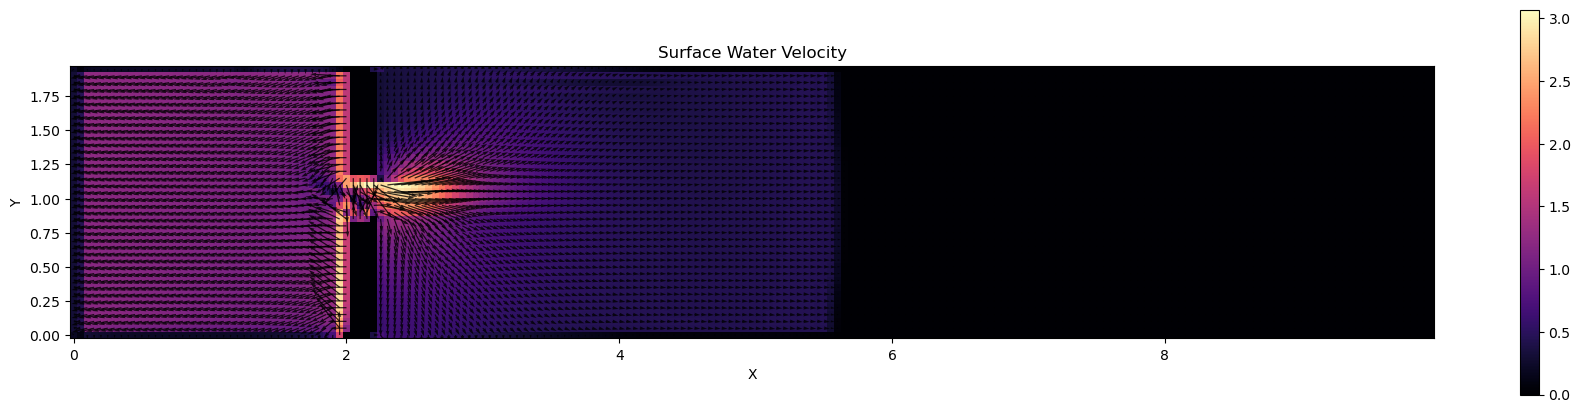

In [52]:
# plot surface velocity field
fig, ax = plt.subplots(figsize=(22, 5))

vx, vy = grid.map_link_vector_components_to_node(grid["link"]["surface_water__velocity"])
vel_magnitude = np.sqrt(vx**2 + vy**2)

imshow_grid(grid, vel_magnitude, cmap="magma")

ax.quiver(
    grid.x_of_node, grid.y_of_node, 
    vx, vy, 
    color="black", 
    scale=100.0,
    width=.0009,
    alpha=0.8
)

plt.title("Surface Water Velocity")
plt.show()

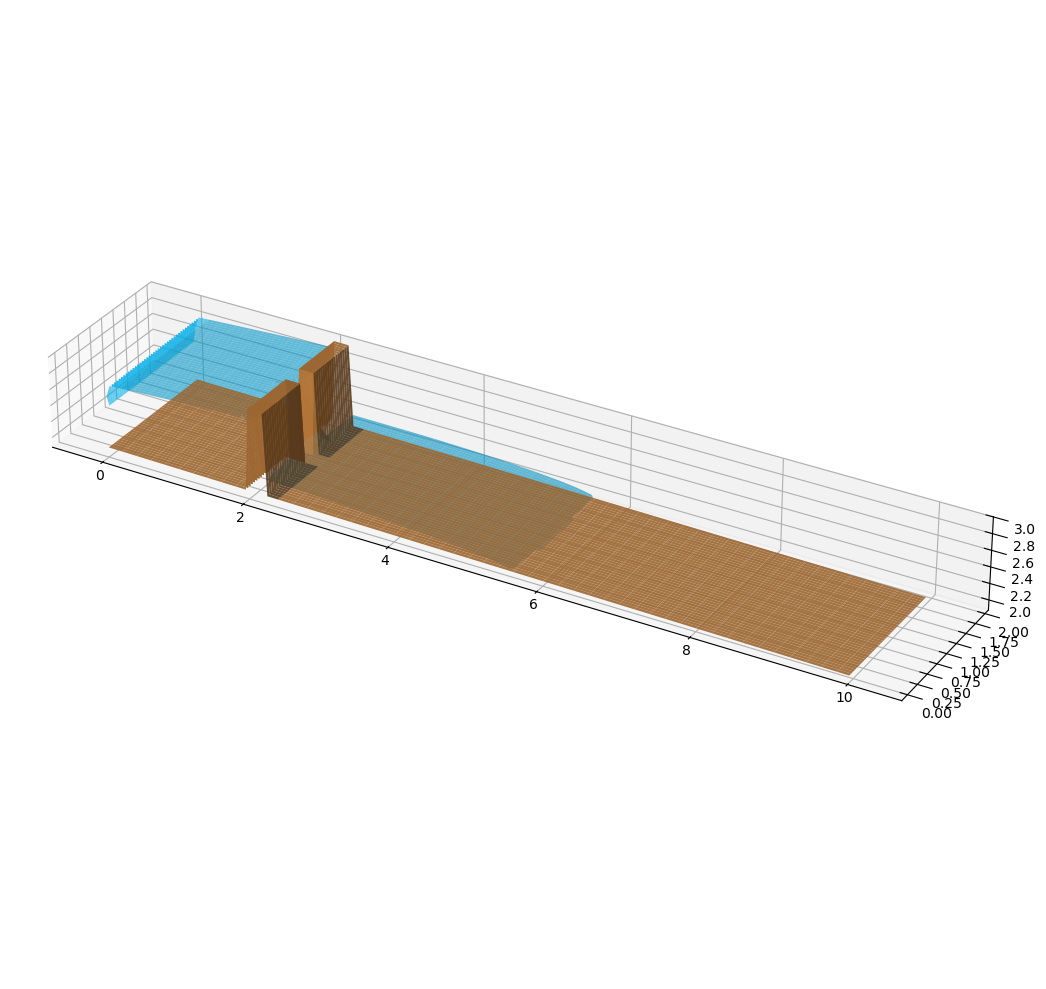

In [53]:
# plot water surface elevation 3d
X_bed = grid.x_of_node.reshape(grid.shape)
Y_bed = grid.y_of_node.reshape(grid.shape)
Z_bed = z.reshape(grid.shape)

depth_2d = grid.at_node["surface_water__depth"].reshape(grid.shape)
wse_2d = (grid.at_node["topographic__elevation"] + grid.at_node["surface_water__depth"]).reshape(grid.shape)

Z_water = grid.at_node["topographic__elevation"] + grid.at_node["surface_water__depth"]
Z_water = Z_water.reshape((n_rows, n_cols))
Z_water = np.ma.masked_where(depth_2d <= 0.01, wse_2d) # mask out dry areas for plot

x_range = X_bed.max() - X_bed.min()  
y_range = Y_bed.max() - Y_bed.min()  
z_range = Z_bed.max() - Z_bed.min() 
vertical_exaggeration = 1.0  
scaled_z_range = z_range * vertical_exaggeration

fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10))

surf1 = ax.plot_surface(
    X_bed, Y_bed, Z_bed, 
    color='peru',      
    edgecolor="none",    
    antialiased=True,
    alpha=.9
)

surf2 = ax.plot_surface(
    X_bed, Y_bed, Z_water, 
    color='deepskyblue',      
    edgecolor="none",    
    antialiased=True,
    alpha=.6
)

ax.set_box_aspect((x_range, y_range, scaled_z_range))
ax.view_init(elev=30, azim=-60)
plt.tight_layout()
plt.show()

In [54]:
X_2d = grid.x_of_node.reshape((n_rows, n_cols))
Y_2d = grid.y_of_node.reshape((n_rows, n_cols))
Z_bed_2d = grid.at_node["topographic__elevation"].reshape((n_rows, n_cols))

stride = 1
X_plot = X_2d[::stride, ::stride]
Y_plot = Y_2d[::stride, ::stride]
Z_bed_plot = Z_bed_2d[::stride, ::stride]

In [56]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

z_min, z_max = Z_bed_2d.min(), (Z_bed_2d.max() + 0.3)

def update_3d_frame(frame_idx):
    ax.clear()  

    depth_2d = grid.at_node["surface_water__depth"].reshape(grid.shape)
    wse_2d = wse_history[frame_idx].reshape((n_rows, n_cols))
    wse_2d = np.ma.masked_where(depth_2d <= 0.01, wse_2d) # mask out dry areas for plot
    wse_plot = wse_2d[::stride, ::stride]

    ax.plot_surface(X_plot, Y_plot, Z_bed_plot, color='peru', edgecolor='none', alpha=0.9)

    ax.plot_surface(X_plot, Y_plot, wse_plot, color='deepskyblue', edgecolor='none', alpha=0.8)

    ax.set_title(f"Flume Simulation (Frame {frame_idx})", fontsize=14)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_zlim(z_min, z_max)
    ax.set_box_aspect((x_range, y_range, scaled_z_range))
    ax.view_init(elev=25, azim=-55)

anim = animation.FuncAnimation(fig, update_3d_frame, frames=len(wse_history), interval=100)

anim.save("notch_flow_dynamics_3d.gif", writer="pillow", fps=10)
plt.close()

print("File saved as 'notch_flow_dynamics_3d.gif'")

File saved as 'notch_flow_dynamics_3d.gif'
